In [1]:
import sys
import os

# Remove any path that ends with 'LangGraph-Course' or contains a local langgraph folder
#sys.path = [p for p in sys.path if "LangGraph-Course" not in p]
import sys
sys.path.insert(0, r"C:\Users\divya\Desktop\Learn\AI\LangGraph\LangGraph-Course\venv\Lib\site-packages")
import sys
sys.modules.pop("langgraph", None)


In [2]:
import langgraph
import langgraph
print(langgraph.__file__)



None


In [1]:
import pkgutil

for module in pkgutil.iter_modules():
    if "langgraph" in module.name:
        print(module.name)


langgraph_cli
langgraph_sdk


In [2]:
from langgraph.graph import StateGraph, START, END

import inspect
print(inspect.signature(StateGraph.__init__))


(self, state_schema: 'type[StateT]', context_schema: 'type[ContextT] | None' = None, *, input_schema: 'type[InputT] | None' = None, output_schema: 'type[OutputT] | None' = None, **kwargs: 'Unpack[DeprecatedKwargs]') -> 'None'


# Multiple Schemas

    - Internal nodes may pass information that is not required in the graph's input / output.
    - We may also want to use different input / output schemas for the graph. The output might, for example, only contain a single relevant output key.

## Input State: The minimum information your graph needs to start running.
The graph must receive input when it starts.

Think of it as:  “What does the user give me at the beginning?”

## Output State: The shape of the state when the graph finishes.

Think of it as:  “What should the graph produce at the end?”

## Private State:
Think of it as:  “Temporary scratch space for the agent.”

1. Pass private state between nodes :
- In some cases, you may want nodes to exchange information that is crucial for intermediate logic but doesn’t need to be part of the main schema of the graph.
- This private data is not relevant to the overall input/output of the graph and should only be shared between certain nodes.
- This is useful for anything needed as part of the intermediate working logic of the graph, but not relevant for the overall graph input or output.

Why it matters:  
It keeps your input/output clean while still letting nodes store extra data.

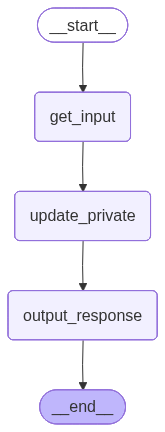

In [3]:
# Create input, private and overall states
from IPython.display import Image, display
from langgraph.graph import StateGraph , START, END
from typing import TypedDict

class Input_state(TypedDict):
    name: str

class Output_State(TypedDict):
    Message: str

class Private_state(TypedDict):
    name:str
    age: int
    persnoal_info: str

# Define Nodes and functions
# node 1
def get_input(state:Input_state)->Private_state:
    print("Node 1 : input state")
    ip = state['name']
    return {'name' : ip }

#node 2
def update_private(state:Private_state):
    print("node 2: Private state")
    return {'age': 24 , 'persnoal_info': 'Great Outdoors person. Loves Horse Riding'}

#node 3
def output_response(state:Private_state)->Output_State:
    print("Node 3: output state")
    return {'Message' : state['name'] + " is of age " + str(state['age']) + " and is a " + state['persnoal_info']}

# Build graph
builder = StateGraph(Input_state,  input_schema= Input_state , output_schema=Output_State)


builder.add_node('get_input' , get_input)
builder.add_node('update_private' , update_private)
builder.add_node('output_response' , output_response)

builder.set_entry_point('get_input')
builder.add_edge('get_input', 'update_private')
builder.add_edge('update_private', 'output_response')
builder.add_edge('output_response', END)

# add graph
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
graph.invoke({'name':'George'})

Node 1 : input state
node 2: Private state
Node 3: output state


{'Message': 'George is of age 24 and is a Great Outdoors person. Loves Horse Riding'}